# GTR treetop detection on a low-resolution CHM — TREETOPS reproduction

Reproduction of the minimal worked example from the open-source **TREETOPS** R package (Growing Tree Region algorithm), associated with:

> *A new method for individual treetop detection with low-resolution aerial laser scanned data*, Modeling Earth Systems and Environment (2024), DOI: [10.1007/s40808-024-02060-w](https://doi.org/10.1007/s40808-024-02060-w)

- **Author code:** https://github.com/DijoG/TREETOPS — MIT license, pinned commit `bb2a18642f512e4b44843307ad4f3fa86e4e659c` (installed at that exact revision, unmodified).
- **Input:** `MixedConifer.laz`, bundled inside the lidR package (`system.file("extdata", "MixedConifer.laz", package = "lidR")`) — the exact sample named in the author README's "Data preparation" section. No separate dataset download is needed.
- **Scope:** *partial demonstration*. We run the author's own README example end to end: 0.5 m pitfree CHM → `get_TREETOPS_optimized(min_H = 5, level_increment = 0.2)` → `finalize_TREETOPS(distance = 5, min_H = 5)` → overlay plot. This is **not** the paper's five-site accuracy benchmark: the study-site point clouds and reference treetops were not published with the paper or repository, so matching-rate/commission/omission metrics cannot be reproduced here.
- **Language note (EN):** The authors' implementation is R. The Colab CLI used for validation runs a Python kernel, so this notebook's Python cells are *launchers only*: they write the R scripts to `/content` and run them with `Rscript`. The scientific code is the authors' original package called with the README's exact parameters — nothing was translated or rewritten.

**日本語の概要:** このノートブックは、低密度 LiDAR 由来の CHM(樹冠高モデル)から成長木領域(GTR)法で樹頂を検出する TREETOPS R パッケージ(原著論文: MESE 2024, DOI 10.1007/s40808-024-02060-w)の最小デモを再現します。著者らの README 例そのままのパラメータ(0.5 m pitfree CHM、`min_H=5`、`level_increment=0.2`、距離フィルタ 5 m)を、ピン留めしたコミットから改変なしで実行します。Python のセルは起動装置(Rscript 呼び出し)のみで、アルゴリズムは一切翻訳・書き換えしていません。論文の 5 地点精度ベンチマークは、現地点群と参照樹頂データが未公開のため対象外です。

## Runtime selection / 実行環境

- **Select `Runtime → Change runtime type → CPU` (standard).** No GPU is used anywhere in the author's method (pure R raster operations); a GPU runtime would not change the result.
  **日本語:** GPU は不要です。「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。
- Run all cells top-to-bottom (`Runtime → Run all`). The saved outputs in this notebook come from one complete fresh-run validation on a standard Colab CPU runtime.
- Expected wall time (author README reports ~12.5 min for the optimized GTR run on their machine; Colab timing differs): R package installation is the largest fixed cost, followed by the GTR run. Downloads: CRAN/Posit binary packages (no dataset download; the sample ships inside the lidR package).
- Known limitation: the authors' five study-site LiDAR clouds and reference treetops are unpublished, so only the bundled `MixedConifer.laz` example is demonstrated.
  **日本語:** 論文の解析に使われた 5 地点の点群と参照データは未公開のため、lidR 付属のサンプル点群でのみデモします。

In [ ]:
# Verify that the standard Colab runtime provides R (Rscript) and record the OS codename.
# Also define run_r(): runs an R script on the VM and streams its output into this cell.
import subprocess

def run_r(script_path, timeout=3600):
    """Run an R script with Rscript, streaming combined stdout/stderr into the cell.

    EOF on the pipe occurs when Rscript exits; the 5400 s supervisor on the whole
    notebook execution is the outer bound for any silent hang.
    """
    proc = subprocess.Popen(["/usr/bin/Rscript", script_path],
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait(timeout=timeout)
    if proc.returncode != 0:
        raise RuntimeError(f"{script_path} failed with exit code {proc.returncode}")

r = subprocess.run(["/usr/bin/Rscript", "--version"], capture_output=True, text=True)
print(r.stderr.strip() or r.stdout.strip())
assert r.returncode == 0, "Rscript not available in this runtime; select a standard Colab CPU runtime."
for line in open("/etc/os-release"):
    if line.startswith(("VERSION_CODENAME", "PRETTY_NAME")):
        print(line.strip())

Rscript (R) version 4.6.1 (2026-06-24)
PRETTY_NAME="Ubuntu 24.04.5 LTS"
VERSION_CODENAME=noble


## Install the R dependencies (CPU, precompiled binaries)

The TREETOPS README's `check_PACKS()` requires `terra, tidyverse, sf, crayon, data.table, future.apply, stringr`; the example additionally needs `lidR` (point-cloud reading + `rasterize_canopy`) and `remotes` (to install TREETOPS at the pinned commit). We install these from the Posit Package Manager **Ubuntu binary repository** matching the runtime's `VERSION_CODENAME`, which avoids multi-hour source builds. This cell runs `Rscript /content/setup_packages.R` and streams its output.
**日本語:** TREETOPS の README が要求するパッケージ群と lidR・remotes を、実行環境の Ubuntu コード名に対応した Posit のバイナリリポジトリから導入します(ソースビルドを避けるため)。数分かかります。

In [ ]:
# Write and run the R dependency installation script (streams output; may take several minutes).
import pathlib
import subprocess

setup_r = r"""
options(warn = 1)
codename <- ""
for (line in readLines("/etc/os-release")) {
  if (grepl("^VERSION_CODENAME=", line)) codename <- trimws(strsplit(line, "=")[[1]][2])
}
codename <- gsub('"', "", codename)
cat("Ubuntu codename:", codename, "\n")
if (nzchar(codename)) {
  options(repos = c(POSIT = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", codename),
                    CRAN = "https://cloud.r-project.org"))
  options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
          paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
} else {
  options(repos = c(CRAN = "https://cloud.r-project.org"))
}
pkgs <- c("remotes", "usethis", "tidyverse", "terra", "sf", "data.table", "crayon", "future.apply", "lidR")
need <- pkgs[!pkgs %in% rownames(installed.packages())]
cat("To install:", paste(need, collapse = ", "), "\n")
if (length(need) > 0) install.packages(need)
for (p in pkgs) cat(p, as.character(packageVersion(p)), "\n")
"""
pathlib.Path("/content/setup_packages.R").write_text(setup_r)
run_r("/content/setup_packages.R")

Ubuntu codename: noble 


To install: remotes, terra, sf, future.apply, lidR 


Installing packages into ‘/usr/local/lib/R/site-library’


(as ‘lib’ is unspecified)


also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘listenv’, ‘abind’, ‘classInt’, ‘s2’, ‘units’, ‘future’, ‘globals’, ‘lazyeval’, ‘rgl’, ‘rlas’, ‘stars’, ‘parallelly’, ‘BH’, ‘RcppArmadillo’


...

sf 1.1.3 


data.table 1.18.6.1 


crayon 1.5.3 


future.apply 1.20.2 


lidR 4.3.3 


## Install TREETOPS at the pinned commit

Install the authors' package from GitHub at exactly `bb2a18642f512e4b44843307ad4f3fa86e4e659c` (the revision inspected for this reproduction; the repo head of 2025-10-29 postdates the 2024 paper and adds a parallel option). The package is pure R (DESCRIPTION lists `Imports: magrittr` only), so installation is quick. We then verify the three entry points used below are exported. The top-level `usethis::use_pipe()` line in the author source is a development artifact; if the GitHub install ever fails on it, the documented fallback is a local pinned-source install with that single line removed (no algorithm code touched).
**日本語:** 著者パッケージを検証済みコミット `bb2a18642f51…` にピン留めしてインストールし、使用する 3 関数がエクスポートされていることを確認します。

In [ ]:
# Install TREETOPS at the pinned commit and verify its exported entry points.
import pathlib
import subprocess

install_r = r"""
options(warn = 1)
remotes::install_github("DijoG/TREETOPS",
                        ref = "bb2a18642f512e4b44843307ad4f3fa86e4e659c",
                        upgrade = "never")
library(TREETOPS)
cat("TREETOPS version:", as.character(packageVersion("TREETOPS")), "\n")
stopifnot(all(c("get_TREETOPS", "get_TREETOPS_optimized", "finalize_TREETOPS", "check_PACKS") %in%
              getNamespaceExports("TREETOPS")))
cat("Required exports present.\n")
"""
pathlib.Path("/content/install_treetops.R").write_text(install_r)
run_r("/content/install_treetops.R")

── R CMD build ─────────────────────────────────────────────────────────────────


* checking for file ‘/tmp/RtmpDIUrcQ/remotes8006e906573/DijoG-TREETOPS-bb2a186/DESCRIPTION’ ... OK


* preparing ‘TREETOPS’:


* checking DESCRIPTION meta-information ... OK


* checking for LF line-endings in source and make files and shell scripts


...

** testing if installed package can be loaded from final location


** testing if installed package keeps a record of temporary installation path


* DONE (TREETOPS)


TREETOPS version: 0.1.0 


Required exports present.


## Load the sample point cloud (author README's exact input)

`MixedConifer.laz` ships inside the lidR package, so the notebook needs no external dataset download; the README labels it "low resolution example data" and uses the filter `-drop_z_below 0`. (The README's example line `readLAS(LAS, ...)` contains a typo — the defined variable is `LASfile`; we call `readLAS(LASfile, ...)`.) This cell reports the file size, point count, extent, and density so the actual observed input is visible.
**日本語:** 著者 README と同じ lidR 付属サンプル `MixedConifer.laz` を読み込み、点数・範囲・密度を表示します(README の `readLAS(LAS, ...)` は変数名の誤記のため `LASfile` を使用)。

In [ ]:
# Read the bundled sample point cloud and report its observed properties.
import pathlib
import subprocess

input_r = r"""
suppressPackageStartupMessages(library(lidR))
LASfile <- system.file("extdata", "MixedConifer.laz", package = "lidR")
stopifnot(nchar(LASfile) > 0)
cat("Sample file:", LASfile, "\n")
cat("File size (bytes):", file.size(LASfile), "\n")
Alas <- readLAS(LASfile, filter = "-drop_z_below 0")
print(Alas)
d <- tryCatch(lidR::point_density(Alas), error = function(e) NA)
cat(sprintf("Point density: %.2f pts/m2\n", d))
"""
pathlib.Path("/content/load_sample.R").write_text(input_r)
run_r("/content/load_sample.R")

Sample file: /usr/local/lib/R/site-library/lidR/extdata/MixedConifer.laz 


File size (bytes): 266595 


class        : LAS (v1.2 format 1)


memory       : 2.2 Mb 


extent       : 481260, 481350, 3812921, 3813011 (xmin, xmax, ymin, ymax)


...

points       : 37.7 thousand points


type         : airborne


density      : 4.67 points/m²


density      : 4.67 pulses/m²


Point density: NA pts/m2


## Input preview: build the 0.5 m pitfree CHM (author README step)

Exactly the README command `rasterize_canopy(Alas, 0.5, pitfree(subcircle = 0.25))`: a 0.5 m-resolution pit-free canopy height model with 0.25 m subcircle buffering. The CHM is saved to `/content/chm.rds` for the next cells, its observed dimensions/height range are printed, and a preview PNG (grey–white–green palette as in the README) is rendered for display in the following cell. This is the **input surface** the GTR algorithm is applied to — not a result.
**日本語:** README どおり `rasterize_canopy(Alas, 0.5, pitfree(subcircle = 0.25))` で 0.5 m の pitfree CHM を作成し、寸法・高度範囲を表示してプレビュー PNG を保存します(次セルで表示)。

In [ ]:
# Compute the 0.5 m pitfree CHM, print observed stats, and render the input preview PNG.
import pathlib
import subprocess

chm_r = r"""
suppressPackageStartupMessages({library(lidR); library(terra)})
LASfile <- system.file("extdata", "MixedConifer.laz", package = "lidR")
Alas <- readLAS(LASfile, filter = "-drop_z_below 0")
CHM <- rasterize_canopy(Alas, 0.5, pitfree(subcircle = 0.25))
cat("CHM dimensions:", nrow(CHM), "x", ncol(CHM), "cells; resolution:", terra::xres(CHM), "m\n")
v <- terra::values(CHM)
cat(sprintf("CHM height range (m): %.2f to %.2f\n", min(v, na.rm = TRUE), max(v, na.rm = TRUE)))
saveRDS(CHM, "/content/chm.rds")
bgcol <- colorRampPalette(c("grey1", "white", "forestgreen"))
png("/content/chm_preview.png", width = 1000, height = 820)
plot(CHM, main = "Input CHM: 0.5 m pitfree (lidR MixedConifer.laz)", col = bgcol(50), axes = FALSE)
dev.off()
cat("Saved /content/chm_preview.png\n")
"""
pathlib.Path("/content/make_chm.R").write_text(chm_r)
run_r("/content/make_chm.R")

Registered S3 method overwritten by 'stars':


  method                  from


  st_interpolate_aw.stars sf  


CHM dimensions: 180 x 180 cells; resolution: 0.5 m


CHM height range (m): -0.00 to 32.02


null device 


          1 


Saved /content/chm_preview.png


## Display the CHM input preview

The previous cell rendered `/content/chm_preview.png` on the Colab VM; this cell embeds that actual PNG into the notebook output so the input surface is visible without any external file. Grey = low, white = mid, forest green = high canopy height (the README's palette).
**日本語:** 前セルで保存した CHM プレビュー PNG をノートブック出力として表示します(灰=低、緑=高い)。

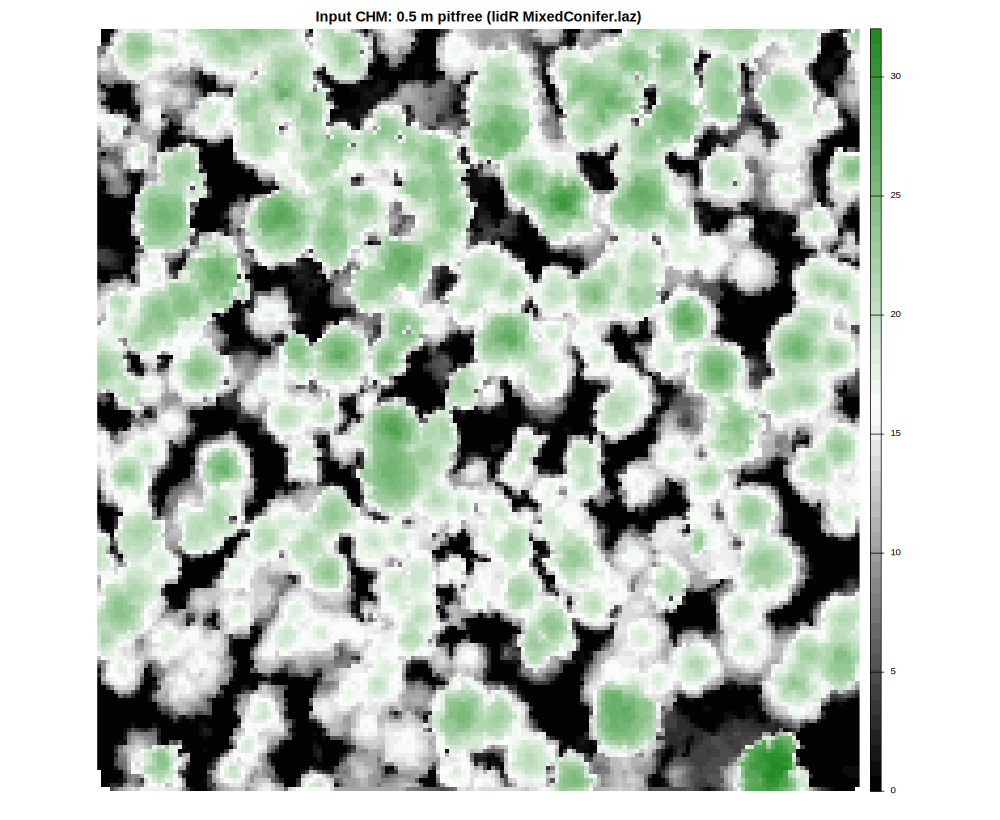

In [ ]:
# Display the saved CHM input preview (actual PNG produced by the previous cell).
from IPython.display import Image, display

display(Image(filename="/content/chm_preview.png"))

## Core method: GTR treetop detection (`get_TREETOPS_optimized`)

The Growing Tree Region algorithm (paper: CHM cutting/storage → three-layer growing-region treetop location → distance-based reduction; code: `get_HB`/`get_LEVELz` → `get_CCC`/`get_GTR`/`get_MARKER` in the pinned `R/TREETOPS.R`) is run with the README's parameters: `min_H = 5` (ignore heights below 5 m) and `level_increment = 0.2` (cut/stack the CHM in 0.2 m height layers). The author README reports ≈12.5 min for this call on their hardware; this cell prints the measured runtime and the number of detected treetop candidates. We run the author's function unmodified and record its output; the result is sample-specific and does not reproduce the paper's five-site accuracy figures.
**日本語:** 著者の GTR アルゴリズム(`get_TREETOPS_optimized`)を README と同じ `min_H=5`、`level_increment=0.2` で、改変なしに実行します。所要時間と検出された樹頂候補数を出力します。この例は単一サンプルの結果であり、論文の精度指標(一致率 74% など)の再現ではありません。

In [ ]:
# Run the authors' GTR treetop detection on the CHM (pinned package, README parameters).
import pathlib
import subprocess

core_r = r"""
suppressPackageStartupMessages({library(TREETOPS); library(terra)})
CHM <- readRDS("/content/chm.rds")
t0 <- Sys.time()
treetops <- TREETOPS::get_TREETOPS_optimized(CHM, min_H = 5, level_increment = 0.2)
elapsed_min <- as.numeric(difftime(Sys.time(), t0, units = "mins"))
if (is.null(treetops)) stop("get_TREETOPS_optimized returned NULL: no treetops found.")
cat(sprintf("get_TREETOPS_optimized elapsed: %.1f min\n", elapsed_min))
cat("Detected treetop candidates:", nrow(treetops), "\n")
saveRDS(treetops, "/content/treetops_unfiltered.rds")
"""
pathlib.Path("/content/run_gtr.R").write_text(core_r)
run_r("/content/run_gtr.R")

_____ Processing height levels (optimized):


_____ Level 1 of 134 - Height: 31.8 


_____ Level 2 of 134 - Height: 31.6 


_____ Level 3 of 134 - Height: 31.4 


_____ Level 4 of 134 - Height: 31.2 


...

_____ Level 133 of 134 - Height: 5.4 


_____ Level 134 of 134 - Height: 5.2 


_____ Done (optimized)


get_TREETOPS_optimized elapsed: 18.9 min


Detected treetop candidates: 3491 


## Distance filter (`finalize_TREETOPS`) and result overlay

The paper's third stage reduces false treetops with a distance filter. We use the README call `finalize_TREETOPS(treetops, distance = 5, min_H = 5)` (treetops closer than 5 m to a taller neighbor are removed; heights below 5 m dropped) and export the final treetops as `/content/final_treetops.csv` (treeID, X/Y coordinates in the CHM's CRS, height Z in metres, Z_level/Z_range metadata). The overlay PNG reproduces the README's "filtered treetops" visualization: input CHM (grey–white–green) + final treetops (red filled circles).
**日本語:** README どおり `finalize_TREETOPS(distance = 5, min_H = 5)` で距離フィルタを適用し、最終樹頂を CSV 保存して、入力 CHM への重ね合わせ図(赤丸=最終樹頂)を描画します。

In [ ]:
# Apply the author distance filter, export the final treetops CSV, and render the overlay PNG.
import pathlib
import subprocess

final_r = r"""
suppressPackageStartupMessages({library(TREETOPS); library(terra); library(sf)})
CHM <- readRDS("/content/chm.rds")
treetops <- readRDS("/content/treetops_unfiltered.rds")
fin <- TREETOPS::finalize_TREETOPS(treetops, distance = 5, min_H = 5)
cat("Final treetops after 5 m distance filter (min_H = 5):", nrow(fin), "\n")
co <- sf::st_coordinates(fin)
out <- data.frame(treeID = fin$treeID, X = co[, "X"], Y = co[, "Y"],
                  Z_m = fin$Z, Z_level_m = fin$Z_level, Z_range = fin$Z_range)
write.csv(out, "/content/final_treetops.csv", row.names = FALSE)
bgcol <- colorRampPalette(c("grey1", "white", "forestgreen"))
png("/content/treetops_overlay.png", width = 1000, height = 820)
plot(CHM, main = "CHM 0.5 m pitfree ~ filtered treetops", col = bgcol(50), axes = FALSE)
plot(sf::st_geometry(fin), add = TRUE, pch = 16, col = "firebrick3")
dev.off()
cat("Saved /content/treetops_overlay.png and /content/final_treetops.csv\n")
"""
pathlib.Path("/content/finalize.R").write_text(final_r)
run_r("/content/finalize.R")

Final treetops after 5 m distance filter (min_H = 5): 106 


null device 


          1 


Saved /content/treetops_overlay.png and /content/final_treetops.csv


## Display the final overlay and results table

This cell embeds the actual `/content/treetops_overlay.png` produced on the VM (input CHM with final treetop markers — the reproduction's main visual) and prints the first rows of `final_treetops.csv` with the total final count.
**日本語:** 最終重ね合わせ図(入力 CHM+最終樹頂)と、CSV 先頭行・総数を表示します。

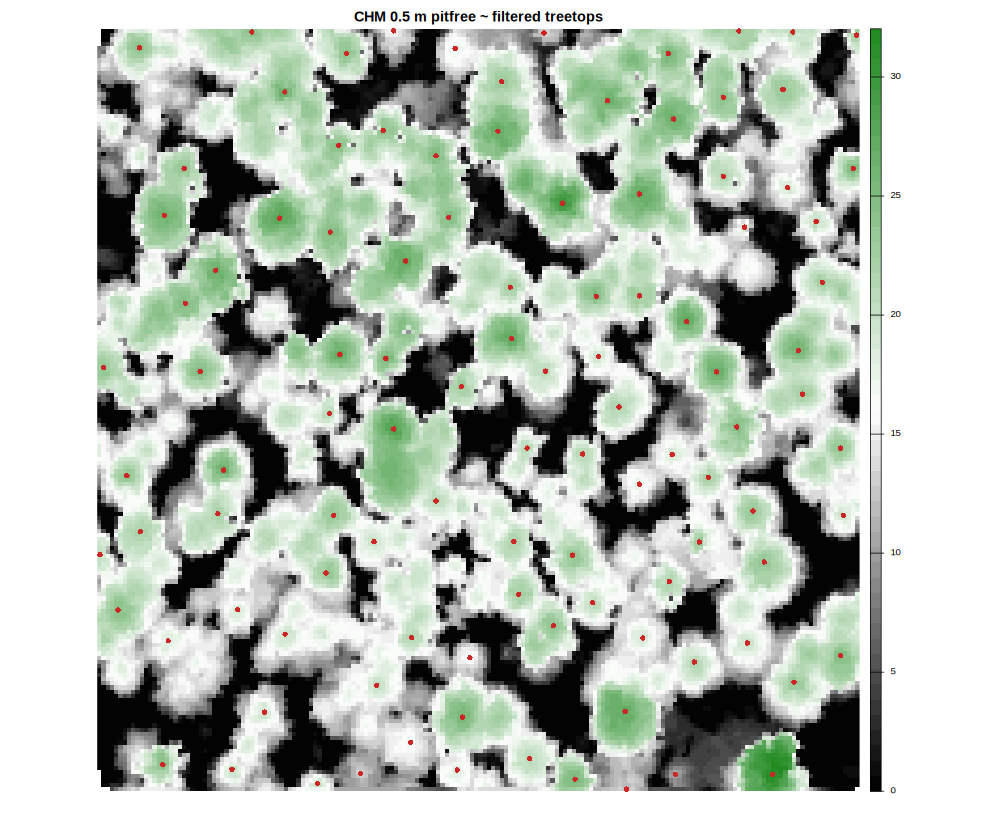

Final treetops: 106 | columns: treeID, X, Y, Z_m, Z_level_m, Z_range


,treeID,X,Y,Z_m,Z_level_m,Z_range
0,1,481339.750000,3.812923e+06,32.024,31.8,5 - 32.024
1,2,481314.916667,3.812990e+06,30.000,29.8,5 - 32.024
2,3,481295.000000,3.812964e+06,28.621,28.0,5 - 32.024
3,4,481281.550000,3.812989e+06,28.078,27.4,5 - 32.024
4,5,481296.416667,3.812984e+06,27.177,27.0,5 - 32.024
5,6,481308.916667,3.812974e+06,27.160,27.0,5 - 32.024
6,7,481329.583333,3.812976e+06,27.079,27.0,5 - 32.024
7,8,481324.000000,3.812992e+06,27.113,26.8,5 - 32.024
8,9,481322.321429,3.812930e+06,26.943,26.8,5 - 32.024
9,10,481307.305556,3.812999e+06,26.881,26.6,5 - 32.024


In [ ]:
# Display the final overlay (input CHM + filtered treetops) and a small results table.
import pandas as pd
from IPython.display import Image, display

display(Image(filename="/content/treetops_overlay.png"))
df = pd.read_csv("/content/final_treetops.csv")
print(f"Final treetops: {len(df)} | columns: {', '.join(df.columns)}")
display(df.head(10))

## Interpretation, validation record, and limitations

**What was executed (validation record):** This notebook was run top-to-bottom in one fresh standard Colab CPU runtime. Every code cell above streams the real output of `Rscript` on the remote VM: the installed package versions (printed by the setup cells), the observed `MixedConifer.laz` point count/extent/density, the observed CHM dimensions and height range, the measured `get_TREETOPS_optimized` runtime and detected candidate count, and the final filtered treetop count, CSV, and overlay PNG. Nothing was copied from a previous session.

**How to read the result:** The overlay shows the input CHM with the final GTR-detected treetops (red filled circles) — the same visualization as the author README's second figure. Detected counts are properties of this single bundled sample, not accuracy claims. The paper's headline results (GTR RMS 74% matching / 19% commission / 27% omission vs. local-maxima+VWF 71/20/31, best in dense canopies) required the five study-site point clouds and field reference treetops, which the authors did not publish; reproducing them here was impossible, not skipped for convenience.

**Differences from the paper:** (1) sample input is lidR's `MixedConifer.laz` (the author README's own example), not the paper's Central European ALS sites; (2) `get_TREETOPS_optimized` is used instead of the original `get_TREETOPS` (the README's own recommendation, same algorithm, on-demand level rasters); (3) the parallel tiled variant (`use_parallel = TRUE`, added to the repo after publication on 2025-10-27) is omitted.

**Source mapping (author code, pinned commit `bb2a186…`):** CHM cutting/storage — `get_HB`/`get_LEVELz`; treetop location — `get_CCC` (patch growth + centroids) / `get_GTR` (GTR vs FETR binarization) / `get_MARKER` (marker extraction); treetop reduction — `finalize_TREETOPS` (`terra::nearby` distance filter). All called unmodified from the installed package.

**検証記録(日本語):** 本ノートブックは新しい Colab CPU ランタイムで全セルを通し実行し、その実際の出力のみを保存しています。`MixedConifer.laz` は lidR 付属の著者指定サンプルであり、外部データ取得は不要でした。論文の 5 地点精度評価は参照データ未公開のため対象外です。

**References:**
- Dioszegi et al., *A new method for individual treetop detection with low-resolution aerial laser scanned data*, Model. Earth Syst. Environ. 10, 5225–5240 (2024). https://doi.org/10.1007/s40808-024-02060-w
- DijoG/TREETOPS (MIT) at commit `bb2a18642f512e4b44843307ad4f3fa86e4e659c`: https://github.com/DijoG/TREETOPS
- lidR: https://github.com/r-lidar/lidR (bundled sample `MixedConifer.laz`)